In [ ]:
# Load the Drive helper and mount:
from google.colab import drive

# This will prompt for authorization:
drive.mount('/content/drive',force_remount=False)

%cd /content/drive/MyDrive/MouseWound/Healnet_Models/DeepMapper_Analysis

Mounted at /content/drive
/content/drive/MyDrive/MouseWound/Healnet_Models/DeepMapper_Analysis


In [ ]:
import csv
import numpy as np
import pandas as pd
import glob

In [ ]:
#!unzip deepmapper_on_testing_mouse_imgage.zip -x "__MACOSX/*" "*.DS_Store"

## Examine one .csv file

### Import Data

In [ ]:
expert_labels

,Image,hemostasis,inflammatory,proliferative,maturation
0,Day 0_A8-5-L.png,1,0,0,0
1,Day 0_A8-3-L.png,1,0,0,0
2,Day 0_A8-1-L.png,0,1,0,0
3,Day 0_A8-4-L.png,1,0,0,0
4,Day 0_A8-4-R.png,1,0,0,0
...,...,...,...,...,...
249,Day 15_Young_Y8-3-L.png,0,0,0,1
250,Day 15_Young_Y8-1-R.png,0,0,0,1
251,Day 15_Young_Y8-3-R.png,0,0,0,1
252,Day 15_Young_Y8-4-R.png,0,0,0,1


In [ ]:
columns = ["Image", "hemostasis", "inflammatory", "proliferative", "maturation"]
stage_cols = columns[1:]


In [ ]:
example = "./deepmapper_on_testing_mouse_imgage/adult/mouse_test_stages_seed_0.csv"
expert_labels = pd.read_csv("../Experts_Cropped_Images_Wound_Stage_Probabilities_from_table.csv")
expert_labels["label_idx"] = expert_labels[stage_cols].values.argmax(axis=1)

expert_labels["Image"] = (
    expert_labels["Image"]
    .astype(str)
    .str.replace("Young_", "", regex=False)
)

In [ ]:
# load predictions .csv as list (for ease of compute later)
rows = []
with open(example, newline="") as f:
    reader = csv.reader(f)
    header = next(reader)
    data = list(reader)

# print(header)
# print(data[0])

### Visualize DeepMapper Data

In [ ]:
#visualize data
data_df = pd.DataFrame(data, columns=columns)

In [ ]:
data_df.head()

,Image,hemostasis,inflammatory,proliferative,maturation
0,Day 0_A8-1-L.png,1.0,0.0,0.0,0.0
1,Day 1_A8-1-L.png,0.598047459842907,0.40195254015709303,0.0,0.0
2,Day 2_A8-1-L.png,0.3480915664733608,0.5435975304133234,0.10831090311331582,0.0
3,Day 3_A8-1-L.png,0.2171105787358418,0.4305718614578983,0.30074079058691094,0.05157676921934897
4,Day 4_A8-1-L.png,0.1394018418703596,0.3337643379281234,0.38189776676132814,0.14493605344018887


### Expert Labels

In [ ]:
# all labels
expert_labels

,Image,hemostasis,inflammatory,proliferative,maturation,label_idx
0,Day 0_A8-5-L.png,1,0,0,0,0
1,Day 0_A8-3-L.png,1,0,0,0,0
2,Day 0_A8-1-L.png,0,1,0,0,1
3,Day 0_A8-4-L.png,1,0,0,0,0
4,Day 0_A8-4-R.png,1,0,0,0,0
...,...,...,...,...,...,...
249,Day 15_Y8-3-L.png,0,0,0,1,3
250,Day 15_Y8-1-R.png,0,0,0,1,3
251,Day 15_Y8-3-R.png,0,0,0,1,3
252,Day 15_Y8-4-R.png,0,0,0,1,3


In [ ]:
# test labels
expert_labels[expert_labels['Image'].isin(data_df['Image'])].head()

,Image,hemostasis,inflammatory,proliferative,maturation,label_idx
2,Day 0_A8-1-L.png,0,1,0,0,1
18,Day 1_A8-1-L.png,0,1,0,0,1
34,Day 2_A8-1-L.png,0,1,0,0,1
50,Day 3_A8-1-L.png,0,1,0,0,1
66,Day 4_A8-1-L.png,0,1,0,0,1


### Compute Accuracy

In [ ]:
def predict(data, expert_labels, stage_cols):
    label_lookup = dict(zip(expert_labels["Image"], expert_labels["label_idx"]))  # stage space
    acc = 0
    matched = 0
    preds_out = []

    for row in data:
        img = row[0]
        preds = [float(x) for x in row[1:]]
        pred = int(np.argmax(preds))

        if img not in label_lookup:
            continue

        label = int(label_lookup[img])
        matched += 1
        acc += (pred == label)
        preds_out.append((img, pred))  # keep image so we can order later

    return preds_out, (acc / matched if matched else 0.0)

In [ ]:
preds, acc = predict(data, expert_labels, stage_cols)
print(acc)
print(preds)

0.25
[0, 0, 1, 1, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]


## Computer Averages for Adult

In [ ]:
a_path = "./deepmapper_on_testing_mouse_imgage/adult"
a_csv_files = glob.glob(f"{a_path}/**/*.csv", recursive = True)

In [ ]:
metrics = []

for f_name in a_csv_files:

    rows = []
    with open(f_name, newline="") as f:
        reader = csv.reader(f)
        header = next(reader)
        data = list(reader)

    _, acc = predict(data, expert_labels, stage_cols)

    metrics.append(acc)

In [ ]:
metrics = np.array(metrics)
float(np.mean(metrics)), float(np.std(metrics))


(0.365, 0.07219764539096826)

In [ ]:
import numpy as np
import glob, csv
from sklearn.metrics import confusion_matrix

labels = [0, 1, 2, 3]  # 4 classes

# pick the evaluation image order from the first CSV (consistent order)
a_path = "./deepmapper_on_testing_mouse_imgage/adult"
a_csv_files = glob.glob(f"{a_path}/**/*.csv", recursive=True)

with open(a_csv_files[0], newline="") as f:
    reader = csv.reader(f)
    header = next(reader)
    data0 = list(reader)

img_order = [r[0] for r in data0]

# ground truth in that same order (choose label_idx OR label_idx_mapped)
gt_lookup = dict(zip(expert_labels["Image"], expert_labels["label_idx"]))  # or label_idx
gt = np.array([gt_lookup[i] for i in img_order], dtype=int)

cms = []
accs = []

for f_name in a_csv_files:
    with open(f_name, newline="") as f:
        reader = csv.reader(f)
        header = next(reader)
        data = list(reader)

    # get predictions, returned as list of (img, pred)
    pred_pairs, acc = predict(data, expert_labels, stage_cols)
    accs.append(acc)

    pred_lookup = dict(pred_pairs)
    y_pred = np.array([pred_lookup[i] for i in img_order], dtype=int)

    cms.append(confusion_matrix(gt, y_pred, labels=labels))

cms = np.stack(cms)
mean_cm = cms.mean(axis=0)
std_cm  = cms.std(axis=0)

print("DeepMapper mean CM:\n", mean_cm)
print("DeepMapper std CM:\n", std_cm)
print("Accuracy mean±std:", float(np.mean(accs)), float(np.std(accs)))

DeepMapper mean CM:
 [[0.   0.   0.   0.  ]
 [2.16 3.08 0.75 0.01]
 [0.   0.16 0.76 7.08]
 [0.   0.   0.   2.  ]]
DeepMapper std CM:
 [[0.         0.         0.         0.        ]
 [0.36660606 0.78332624 0.75332596 0.09949874]
 [0.         0.39293765 0.72277244 0.73047929]
 [0.         0.         0.         0.        ]]
Accuracy mean±std: 0.365 0.07219764539096826


In [ ]:
 mean_cm.sum(axis=1, keepdims=True)

array([[0.],
       [6.],
       [8.],
       [2.]])

In [ ]:
row_sums = mean_cm.sum(axis=1, keepdims=True)
mean_cm_row = np.divide(mean_cm, row_sums, out=np.zeros_like(mean_cm), where=row_sums != 0)
print(mean_cm_row)

[[0.         0.         0.         0.        ]
 [0.36       0.51333333 0.125      0.00166667]
 [0.         0.02       0.095      0.885     ]
 [0.         0.         0.         1.        ]]


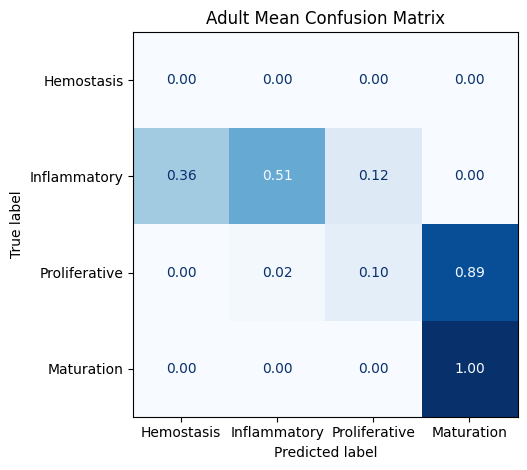

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=mean_cm_row,
    display_labels=["Hemostasis", "Inflammatory", "Proliferative", "Maturation"]
)

fig, ax = plt.subplots()

disp.plot(
    cmap="Blues",
    values_format=".2f",
    colorbar=False,
    ax=ax
)

ax.set_title("Adult Mean Confusion Matrix")

plt.tight_layout()
plt.savefig("adult_cm.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
label_lookup = dict(zip(
    expert_labels["Image"],
    expert_labels["label_idx"]
))

from collections import defaultdict
import numpy as np

day_acc_runs = defaultdict(list)   # day → [acc_run1, acc_run2, ...]

for f_name in a_csv_files:
    with open(f_name, newline="") as f:
        reader = csv.reader(f)
        header = next(reader)
        data = list(reader)

    # predictions
    pred_pairs, _ = predict(data, expert_labels, stage_cols)
    pred_lookup = {norm_name(k): v for k, v in pred_pairs}

    # per-day correctness
    day_hits = defaultdict(list)

    for img_norm, pred in pred_lookup.items():
        if img_norm not in gt_lookup:
            continue

        gt = gt_lookup[img_norm]
        day = extract_day(img_norm)

        day_hits[day].append(pred == gt)

    # aggregate per day for this run
    for day, hits in day_hits.items():
        day_acc_runs[day].append(np.mean(hits))

day_stats = {
    day: (np.mean(accs), np.std(accs))
    for day, accs in day_acc_runs.items()
}

for d in sorted(day_stats):
    mean, std = day_stats[d]
    print(f"Day {d:2d}: {mean:.3f} ± {std:.3f}")

Day  0: 0.000 ± 0.000
Day  1: 0.000 ± 0.000
Day  2: 0.840 ± 0.367
Day  3: 0.990 ± 0.099
Day  4: 0.800 ± 0.400
Day  5: 0.450 ± 0.497
Day  6: 0.560 ± 0.496
Day  7: 0.180 ± 0.384
Day  8: 0.020 ± 0.140
Day  9: 0.000 ± 0.000
Day 10: 0.000 ± 0.000
Day 11: 1.000 ± 0.000
Day 12: 0.000 ± 0.000
Day 13: 0.000 ± 0.000
Day 14: 0.000 ± 0.000
Day 15: 1.000 ± 0.000


## Computer Averages for Young

In [ ]:
y_path = "./deepmapper_on_testing_mouse_imgage/young"
y_csv_files = glob.glob(f"{y_path}/**/*.csv", recursive = True)

In [ ]:
metrics = []

for f_name in y_csv_files:

    rows = []
    with open(f_name, newline="") as f:
        reader = csv.reader(f)
        header = next(reader)
        data = list(reader)

    _, acc = predict(data, expert_labels, stage_cols)

    metrics.append(acc)

In [ ]:
metrics = np.array(metrics)
float(np.mean(metrics)), float(np.std(metrics))

(0.665625, 0.04871392896287467)

In [ ]:
import numpy as np
import glob, csv
from sklearn.metrics import confusion_matrix

labels = [0, 1, 2, 3]  # 4 classes

# pick the evaluation image order from the first CSV (consistent order)
a_path = "./deepmapper_on_testing_mouse_imgage/young"
y_csv_files = glob.glob(f"{a_path}/**/*.csv", recursive=True)

with open(y_csv_files[0], newline="") as f:
    reader = csv.reader(f)
    header = next(reader)
    data0 = list(reader)

img_order = [r[0] for r in data0]

# ground truth in that same order (choose label_idx OR label_idx_mapped)
gt_lookup = dict(zip(expert_labels["Image"], expert_labels["label_idx"]))  # or label_idx
gt = np.array([gt_lookup[i] for i in img_order], dtype=int)

cms = []
accs = []

for f_name in y_csv_files:
    with open(f_name, newline="") as f:
        reader = csv.reader(f)
        header = next(reader)
        data = list(reader)

    # get predictions, returned as list of (img, pred)
    pred_pairs, acc = predict(data, expert_labels, stage_cols)
    accs.append(acc)

    pred_lookup = dict(pred_pairs)
    y_pred = np.array([pred_lookup[i] for i in img_order], dtype=int)

    cms.append(confusion_matrix(gt, y_pred, labels=labels))

cms = np.stack(cms)
mean_cm = cms.mean(axis=0)
std_cm  = cms.std(axis=0)

print("DeepMapper mean CM:\n", mean_cm)
print("DeepMapper std CM:\n", std_cm)
print("Accuracy mean±std:", float(np.mean(accs)), float(np.std(accs)))

DeepMapper mean CM:
 [[1.   0.   0.   0.  ]
 [0.   1.93 0.07 0.  ]
 [0.   1.97 0.72 3.31]
 [0.   0.   0.   7.  ]]
DeepMapper std CM:
 [[0.         0.         0.         0.        ]
 [0.         0.25514702 0.25514702 0.        ]
 [0.         0.84208076 0.76262704 0.62761453]
 [0.         0.         0.         0.        ]]
Accuracy mean±std: 0.665625 0.04871392896287467


In [ ]:
mean_cm_row = mean_cm / mean_cm.sum(axis=1, keepdims=True)
print(mean_cm_row)

[[1.         0.         0.         0.        ]
 [0.         0.965      0.035      0.        ]
 [0.         0.32833333 0.12       0.55166667]
 [0.         0.         0.         1.        ]]


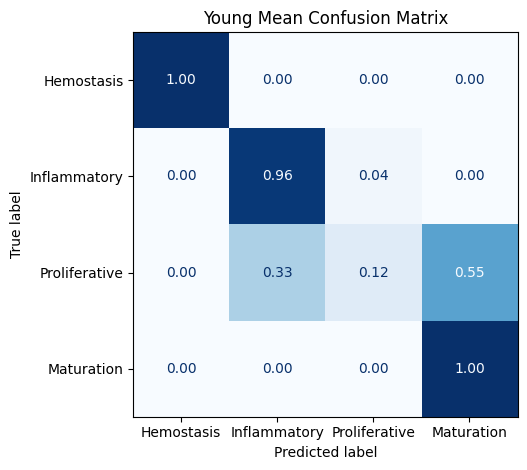

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

disp = ConfusionMatrixDisplay(
    confusion_matrix=mean_cm_row,
    display_labels=["Hemostasis", "Inflammatory", "Proliferative", "Maturation"]
)

disp.plot(
    cmap="Blues",
    values_format=".2f",
    colorbar=False,
    ax=ax
)

ax.set_title("Young Mean Confusion Matrix")

plt.tight_layout()
plt.savefig("young_cm.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
label_lookup = dict(zip(
    expert_labels["Image"],
    expert_labels["label_idx"]
))

from collections import defaultdict
import numpy as np

day_acc_runs = defaultdict(list)

for f_name in y_csv_files:
    with open(f_name, newline="") as f:
        reader = csv.reader(f)
        header = next(reader)
        data = list(reader)

    # predictions
    pred_pairs, _ = predict(data, expert_labels, stage_cols)
    pred_lookup = {norm_name(k): v for k, v in pred_pairs}

    # per-day correctness
    day_hits = defaultdict(list)

    for img_norm, pred in pred_lookup.items():
        if img_norm not in gt_lookup:
            continue

        gt = gt_lookup[img_norm]
        day = extract_day(img_norm)

        day_hits[day].append(pred == gt)

    # aggregate per day for this run
    for day, hits in day_hits.items():
        day_acc_runs[day].append(np.mean(hits))

day_stats = {
    day: (np.mean(accs), np.std(accs))
    for day, accs in day_acc_runs.items()
}

for d in sorted(day_stats):
    mean, std = day_stats[d]
    # print(f"Day {d:2d}: acc = {mean:.3f} ± {std:.3f}")
    print(f"{mean:.3f} ± {std:.3f}")

1.000 ± 0.000
0.000 ± 0.000
1.000 ± 0.000
0.930 ± 0.255
0.340 ± 0.474
0.330 ± 0.470
0.050 ± 0.218
0.000 ± 0.000
0.000 ± 0.000
1.000 ± 0.000
1.000 ± 0.000
1.000 ± 0.000
1.000 ± 0.000
1.000 ± 0.000
1.000 ± 0.000
1.000 ± 0.000


### Metrics on all data:

In [ ]:
data_path = "./deepmapper_on_testing_mouse_imgage/"
csv_files = glob.glob(f"{data_path}/**/*.csv", recursive = True)

In [ ]:
metrics = []

for f_name in csv_files:

    rows = []
    with open(f_name, newline="") as f:
        reader = csv.reader(f)
        header = next(reader)
        data = list(reader)

    _, acc = predict(data, expert_labels, stage_cols)

    metrics.append(acc)

In [ ]:
metrics = np.array(metrics)
float(np.mean(metrics)), float(np.std(metrics))

(0.5153125, 0.16243959213735423)

In [ ]:
import numpy as np, glob, csv
from sklearn.metrics import confusion_matrix

labels = [0,1,2,3]

def norm_name(s):
    s = str(s).strip().split("/")[-1]
    return s.replace("Young_", "")

# lookup once
expert_labels["Image_norm"] = expert_labels["Image"].astype(str).map(norm_name)
gt_lookup = dict(zip(expert_labels["Image_norm"], expert_labels["label_idx"]))  # or label_idx_mapped

cms, accs = [], []

a_path = "./deepmapper_on_testing_mouse_imgage"
csv_files = glob.glob(f"{a_path}/**/*.csv", recursive=True)

for f_name in csv_files:
    with open(f_name, newline="") as f:
        reader = csv.reader(f)
        header = next(reader)
        data = list(reader)

    img_order = [norm_name(r[0]) for r in data]
    pred_pairs, acc = predict(data, expert_labels, stage_cols)
    accs.append(acc)

    pred_lookup = {norm_name(k): v for k, v in pred_pairs}

    common = [i for i in img_order if i in pred_lookup and i in gt_lookup]
    gt = np.array([gt_lookup[i] for i in common], dtype=int)
    y_pred = np.array([pred_lookup[i] for i in common], dtype=int)

    cms.append(confusion_matrix(gt, y_pred, labels=labels))

cms = np.stack(cms)
mean_cm = cms.mean(axis=0)
std_cm  = cms.std(axis=0)

print("Mean CM:\n", cms.mean(axis=0))
print("Std CM:\n", cms.std(axis=0))
print("Acc mean±std:", float(np.mean(accs)), float(np.std(accs)))

Mean CM:
 [[5.000e-01 0.000e+00 0.000e+00 0.000e+00]
 [1.080e+00 2.505e+00 4.100e-01 5.000e-03]
 [0.000e+00 1.065e+00 7.400e-01 5.195e+00]
 [0.000e+00 0.000e+00 0.000e+00 4.500e+00]]
Std CM:
 [[0.5        0.         0.         0.        ]
 [1.11067547 0.81852001 0.65719099 0.07053368]
 [0.         1.11838053 0.74323617 2.00423926]
 [0.         0.         0.         2.5       ]]
Acc mean±std: 0.5153125 0.16243959213735423


In [ ]:
mean_cm_row = mean_cm / mean_cm.sum(axis=1, keepdims=True)
print(mean_cm_row)

[[1.         0.         0.         0.        ]
 [0.27       0.62625    0.1025     0.00125   ]
 [0.         0.15214286 0.10571429 0.74214286]
 [0.         0.         0.         1.        ]]


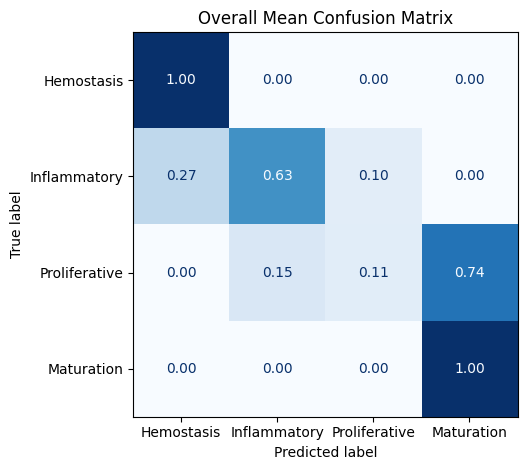

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

disp = ConfusionMatrixDisplay(
    confusion_matrix=mean_cm_row,
    display_labels=["Hemostasis", "Inflammatory", "Proliferative", "Maturation"]
)

disp.plot(
    cmap="Blues",
    values_format=".2f",
    colorbar=False,
    ax=ax
)

ax.set_title("Overall Mean Confusion Matrix")

plt.tight_layout()
plt.savefig("overall_cm.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
csv_files = glob.glob(f"{data_path}/**/*.csv", recursive = True)

label_lookup = dict(zip(
    expert_labels["Image"],
    expert_labels["label_idx"]
))

from collections import defaultdict
import numpy as np

day_acc_runs = defaultdict(list)   # day → [acc_run1, acc_run2, ...]

for f_name in csv_files:
    with open(f_name, newline="") as f:
        reader = csv.reader(f)
        header = next(reader)
        data = list(reader)

    # predictions
    pred_pairs, _ = predict(data, expert_labels, stage_cols)
    pred_lookup = {norm_name(k): v for k, v in pred_pairs}

    # per-day correctness
    day_hits = defaultdict(list)

    for img_norm, pred in pred_lookup.items():
        if img_norm not in gt_lookup:
            continue

        gt = gt_lookup[img_norm]
        day = extract_day(img_norm)

        day_hits[day].append(pred == gt)

    # aggregate per day for this run
    for day, hits in day_hits.items():
        day_acc_runs[day].append(np.mean(hits))

day_stats = {
    day: (np.mean(accs), np.std(accs))
    for day, accs in day_acc_runs.items()
}

for d in sorted(day_stats):
    mean, std = day_stats[d]
    # print(f"Day {d:2d}: acc = {mean:.3f} ± {std:.3f}")
    print(f"{mean:.3f} ± {std:.3f}")

0.500 ± 0.500
0.000 ± 0.000
0.920 ± 0.271
0.960 ± 0.196
0.570 ± 0.495
0.390 ± 0.488
0.305 ± 0.460
0.090 ± 0.286
0.010 ± 0.099
0.500 ± 0.500
0.500 ± 0.500
1.000 ± 0.000
0.500 ± 0.500
0.500 ± 0.500
0.500 ± 0.500
1.000 ± 0.000


In [ ]:
import pandas as pd

data = {
    "Adult":   [0.000,0.000,0.840,0.990,0.800,0.450,0.560,0.180,0.020,0.000,0.000,1.000,0.000,0.000,0.000,1.000],
    "Young":   [1.000,0.000,1.000,0.930,0.340,0.330,0.050,0.000,0.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000],
    "Overall": [0.500,0.000,0.920,0.960,0.570,0.390,0.305,0.090,0.010,0.500,0.500,1.000,0.500,0.500,0.500,1.000]
}

df = pd.DataFrame(data, index=[f"Day {i}" for i in range(16)])

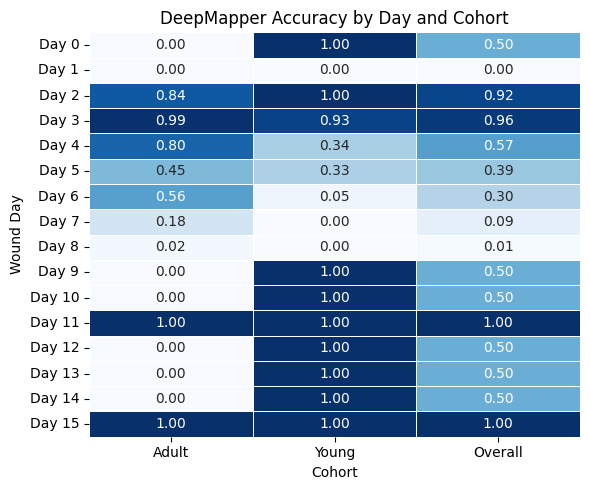

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(
    df,
    cmap="Blues",
    vmin=0, vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar=False
)

plt.title("DeepMapper Accuracy by Day and Cohort")
plt.ylabel("Wound Day")
plt.xlabel("Cohort")

plt.tight_layout()
plt.savefig("deepmapper_accuracy_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()